In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import colorcet as cc
import warnings
import re
import random

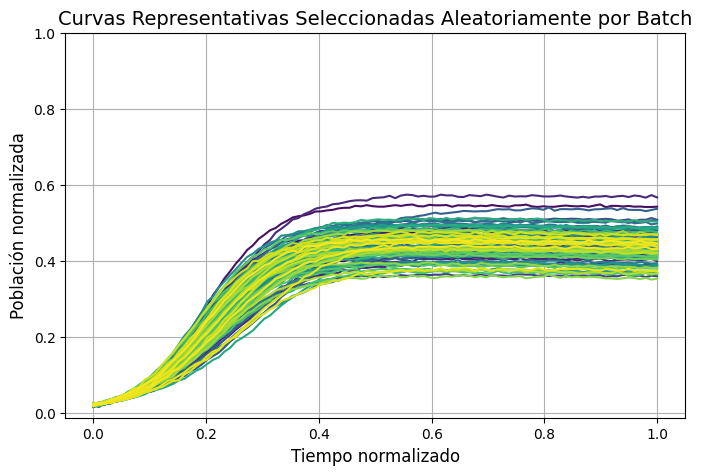

Combinaciones de efectos de drogas:
Tipo 1: Drug 1 Effect = 0.5122, Drug 2 Effect = 0.2644
Tipo 2: Drug 1 Effect = 0.9155, Drug 2 Effect = 0.9289
Tipo 3: Drug 1 Effect = 0.7624, Drug 2 Effect = 0.8327
Tipo 4: Drug 1 Effect = 0.6691, Drug 2 Effect = 0.3986
Tipo 5: Drug 1 Effect = 0.3592, Drug 2 Effect = 0.3773
Tipo 6: Drug 1 Effect = 0.3592, Drug 2 Effect = 0.3784
Tipo 7: Drug 1 Effect = 0.2907, Drug 2 Effect = 0.4630
Tipo 8: Drug 1 Effect = 0.8563, Drug 2 Effect = 0.6173
Tipo 9: Drug 1 Effect = 0.6708, Drug 2 Effect = 0.5524
Tipo 10: Drug 1 Effect = 0.7457, Drug 2 Effect = 0.4539


In [3]:
# Parámetros generales del modelo logístico
K = 500     # Capacidad de carga
P0 = 10     # Población inicial
r = 1.0     # Tasa de crecimiento
decay_rate = 0.005  # Tasa de decaimiento
t = np.linspace(0, 50, 100)  # Tiempo con 100 puntos

# Generar 15 combinaciones aleatorias de drug_1_effect y drug_2_effect entre 0.25 y 1.0
np.random.seed(42)  # Fijar semilla para reproducibilidad
num_types = 10
curves_per_type = 100

# Generar combinaciones aleatorias de efectos de drogas
drug_1_effect_combinations = np.random.uniform(0.25, 0.95, num_types)
drug_2_effect_combinations = np.random.uniform(0.25, 0.95, num_types)

# Guardar las combinaciones en un vector claro
drug_effects_combinations = list(zip(drug_1_effect_combinations, drug_2_effect_combinations))

# Función de crecimiento logístico con decay rate
def logistic_growth_decay(t, K, P0, r, decay_rate):
    logistic = K / (1 + ((K - P0) / P0) * np.exp(-r * t))
    return logistic * np.exp(-decay_rate * t)  # Aplicar decaimiento exponencial

# Crear listas para almacenar las curvas y los batches
curves_list = []
batches_list = []
conditions = []

# Generar curvas y batches
for drug_1_effect, drug_2_effect in drug_effects_combinations:
    # Crear un batch name
    batch_name = f"{drug_1_effect:.4f}_{drug_2_effect:.4f}"
    for _ in range(curves_per_type):
        # Aplicar efectos de drogas
        r_drug = r * drug_1_effect + np.random.normal(0, 0.1 * r * drug_1_effect)   #10% de variación experimental aleatoria en r y K, de esta manera llega a 2 sigmas casi toda la distribucion
        K_drug = K * drug_2_effect + np.random.normal(0, 0.1 * K * drug_2_effect)
        decay_rate = decay_rate + np.random.normal(0, 0.1 * decay_rate)
        # Calcular la curva
        P_t_decay = logistic_growth_decay(t, K_drug, P0, r_drug, decay_rate)

        # Añadir ruido aleatorio a la curva
        noise = np.random.normal(0, 1.0, size=P_t_decay.shape)  # Ruido con desviación estándar 1.0
        P_t_decay_noisy = P_t_decay + noise

        # Normalizar la curva
        P_t_decay_norm_noisy = P_t_decay_noisy / K

        # Almacenar la curva y el batch en las listas
        curves_list.append(P_t_decay_norm_noisy)
        batches_list.append(batch_name)
        conditions.append([drug_1_effect,drug_2_effect])


# Convertir las listas en un DataFrame
df_curves = pd.DataFrame(curves_list).T
C_curves = pd.DataFrame(conditions)

# Seleccionar un batch entero para graficar
unique_batches = list(set(batches_list))
curves_indices = [i for i, b in enumerate(batches_list) if b == unique_batches[-2]]     #AQUI se mearca que curvas graficar para poder ver la variabilidad generada, en función de unique_batches

# Graficar las curvas seleccionadas
plt.figure(figsize=(8, 5))
for idx in curves_indices:
    curve = df_curves[idx]
    batch_name = idx
    plt.plot(
        t / t[-1],
        curve,
        label=batch_name,
        color=plt.cm.viridis(curves_indices.index(idx) / len(curves_indices))
    )

# Configuración del gráfico
plt.title("Curvas Representativas Seleccionadas Aleatoriamente por Batch", fontsize=14)
plt.xlabel("Tiempo normalizado", fontsize=12)
plt.ylabel("Población normalizada", fontsize=12)
#plt.legend(title="Batches", fontsize=8, loc="upper left", bbox_to_anchor=(1, 1))
plt.grid()
plt.yticks(np.arange(0, 1.01, 0.2)) 
#plt.tight_layout()
plt.show()

# Mostrar el DataFrame y la lista de batches
print("Combinaciones de efectos de drogas:")
for idx, (drug1, drug2) in enumerate(drug_effects_combinations, 1):
    print(f"Tipo {idx}: Drug 1 Effect = {drug1:.4f}, Drug 2 Effect = {drug2:.4f}")


In [5]:
unique_batches

['0.3592_0.3784',
 '0.9155_0.9289',
 '0.6691_0.3986',
 '0.7624_0.8327',
 '0.6708_0.5524',
 '0.3592_0.3773',
 '0.7457_0.4539',
 '0.5122_0.2644',
 '0.2907_0.4630',
 '0.8563_0.6173']

In [13]:
curves_indices

[300,
 301,
 302,
 303,
 304,
 305,
 306,
 307,
 308,
 309,
 310,
 311,
 312,
 313,
 314,
 315,
 316,
 317,
 318,
 319,
 320,
 321,
 322,
 323,
 324,
 325,
 326,
 327,
 328,
 329,
 330,
 331,
 332,
 333,
 334,
 335,
 336,
 337,
 338,
 339,
 340,
 341,
 342,
 343,
 344,
 345,
 346,
 347,
 348,
 349]

0.5 0.3
0.3 0.8
0.6 0.5
0.8 0.8


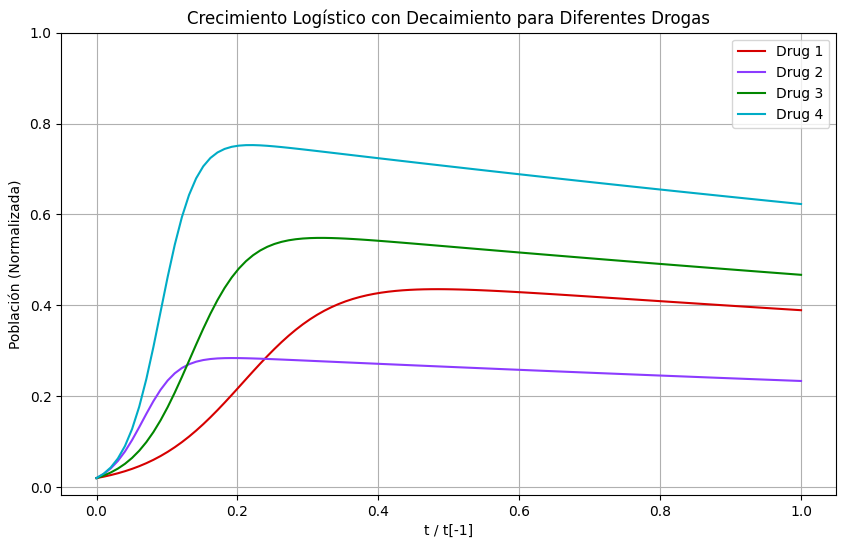

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros comunes
K = 500     # Capacidad de carga
P0 = 10     # Población inicial
r = 1.0     # Tasa de crecimiento
decay_rate = 0.005  # Tasa de decaimiento
t = np.linspace(0, 50, 100)  # Tiempo con 100 puntos
palette=sns.color_palette(cc.glasbey,15)

# Función de crecimiento logístico con decay rate
def logistic_growth_decay(t, K, P0, r, decay_rate):
    logistic = K / (1 + ((K - P0) / P0) * np.exp(-r * t))
    return logistic * np.exp(-decay_rate * t)  # Aplicar decaimiento exponencial

# Parámetros para 4 drogas
drugs = [
    {"name": "Drug 1", "K_factor": 0.5, "r_factor": 0.3},
    {"name": "Drug 2", "K_factor": 0.3, "r_factor": 0.8},
    {"name": "Drug 3", "K_factor": 0.6, "r_factor": 0.5},
    {"name": "Drug 4", "K_factor": 0.8, "r_factor": 0.8},
]

# Crear la gráfica
plt.figure(figsize=(10, 6))

for drug,color in zip(drugs,palette):
    # Ajustar parámetros según la droga
    K_drug = K * drug["K_factor"]
    r_drug = r * drug["r_factor"]
    print(drug["K_factor"],drug["r_factor"])
    # Calcular valores de la función
    population = logistic_growth_decay(t, K_drug, P0, r_drug, decay_rate)
    # Normalizar la curva
    population = population / K
    
    # Crear recta en función de t / t[-1]
    normalized_time = t / t[-1]
    
    # Graficar cada droga
    plt.plot(normalized_time, population, label=drug["name"],color=color)

# Etiquetas y diseño de la gráfica
plt.xlabel("t / t[-1]")
plt.ylabel("Población (Normalizada)")
plt.title("Crecimiento Logístico con Decaimiento para Diferentes Drogas")
plt.yticks(np.arange(0, 1.01, 0.2))
plt.legend()
plt.grid()
plt.show()


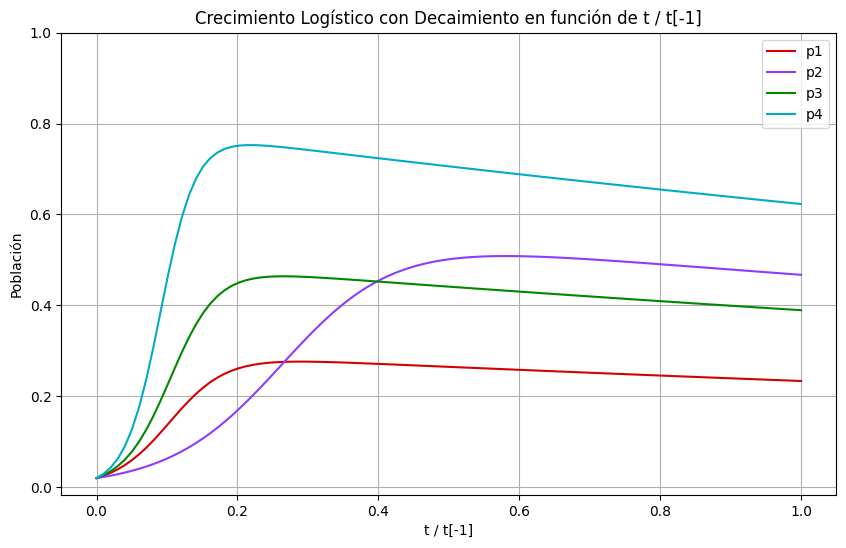

In [16]:
# Parámetros
K = 500     # Capacidad de carga
P0 = 10     # Población inicial
r = 1.0     # Tasa de crecimiento
decay_rate = 0.005  # Tasa de decaimiento
t = np.linspace(0, 50, 100)  # Tiempo con 100 puntos
palette=sns.color_palette(cc.glasbey,15)

# Función de crecimiento logístico con decay rate
def logistic_growth_decay(t, K, P0, r, decay_rate):
    logistic = K / (1 + ((K - P0) / P0) * np.exp(-r * t))
    return logistic * np.exp(-decay_rate * t)  # Aplicar decaimiento exponencial

C1= [0.5, 0.3]
C2= [0.25, 0.6]
C3= [0.6, 0.5]
C4= [0.8, 0.8]
condition = pd.DataFrame([C1,C2,C3,C4])
names=['p1','p2','p3','p4']
# Graficar
plt.figure(figsize=(10, 6))

for drug,color,name in zip(condition.values,palette,names):
    r_drug = r * drug[0]
    K_drug = K * drug[1] 

    # Calcular valores de la función
    population = logistic_growth_decay(t, K_drug, P0, r_drug, decay_rate)
    # Normalizar la curva
    population = population / K

    # Crear recta en función de t / t[-1]
    normalized_time = t / t[-1]

    plt.plot(normalized_time, population, label=name,color=color)

plt.xlabel("t / t[-1]")
plt.ylabel("Población")
plt.title("Crecimiento Logístico con Decaimiento en función de t / t[-1]")
plt.yticks(np.arange(0, 1.01, 0.2)) 
plt.legend()
plt.grid()
plt.show()

In [56]:
C1= [0.5, 0.3]
C2= [0.3, 0.8]
C3= [0.6, 0.5]
C4= [0.8, 0.8]
condition = pd.DataFrame([C1,C2,C3,C4])
for drug in condition.values:
    print(drug[0])

0.5
0.3
0.6
0.8


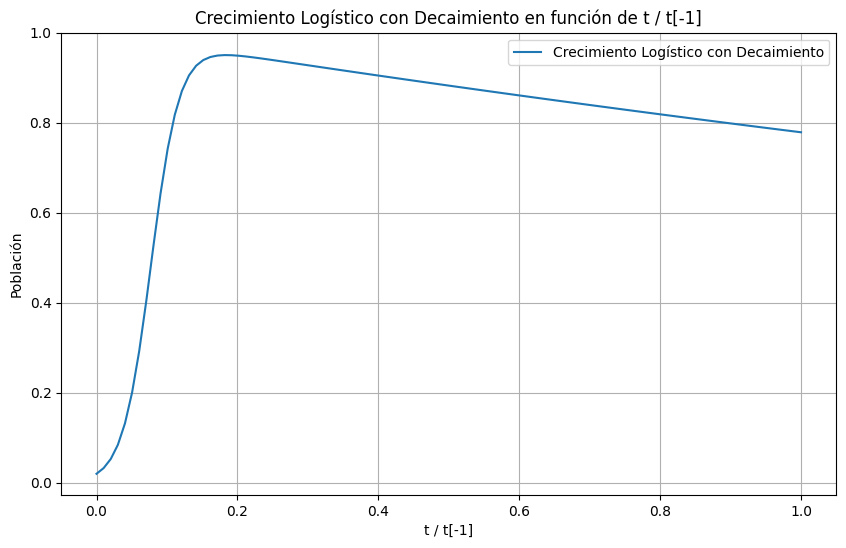

In [31]:
# Parámetros
K = 500     # Capacidad de carga
P0 = 10     # Población inicial
r = 1.0     # Tasa de crecimiento
decay_rate = 0.005  # Tasa de decaimiento
t = np.linspace(0, 50, 100)  # Tiempo con 100 puntos

# Función de crecimiento logístico con decay rate
def logistic_growth_decay(t, K, P0, r, decay_rate):
    logistic = K / (1 + ((K - P0) / P0) * np.exp(-r * t))
    return logistic * np.exp(-decay_rate * t)  # Aplicar decaimiento exponencial

# Calcular valores de la función
population = logistic_growth_decay(t, K, P0, r, decay_rate)
# Normalizar la curva
population = population / K

# Crear recta en función de t / t[-1]
normalized_time = t / t[-1]

# Graficar
plt.figure(figsize=(10, 6))
plt.plot(normalized_time, population, label="Crecimiento Logístico con Decaimiento")
plt.xlabel("t / t[-1]")
plt.ylabel("Población")
plt.title("Crecimiento Logístico con Decaimiento en función de t / t[-1]")
plt.yticks(np.arange(0, 1.01, 0.2)) 
plt.legend()
plt.grid()
plt.show()
